In [11]:
!pip install -q gdown
import os
from pathlib import Path
import gdown

# Data lives in the shared IOAI-2026/RobotDelivery folder (public link, no sign-in).
DATA_DIR = Path('data')
if not DATA_DIR.exists() or not any(DATA_DIR.iterdir()):
    gdown.download_folder(id='1DXFDoY9bqulMBFacyDShVIx8Sa7Z5Wpa',
                          output=str(DATA_DIR), quiet=True, use_cookies=False)
os.listdir(DATA_DIR)

['test_scenarios.pkl', 'train_demos.pkl', 'valid_scenarios.pkl']

In [12]:
import json
import pickle
import random
import zipfile
from collections import Counter
from pathlib import Path
from typing import Any

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from IPython.display import Image as NotebookImage, display
from PIL import Image as PILImage, ImageDraw
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

GRID_SIZE = 8
N_DEPOTS = 6
MAX_STEPS = 120
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ACTION_NAMES = {
    0: "south",
    1: "north",
    2: "east",
    3: "west",
    4: "pickup",
    5: "dropoff",
}

ACTION_DELTAS = {
    0: (1, 0),
    1: (-1, 0),
    2: (0, 1),
    3: (0, -1),
}

DEPOT_NAMES = ["A", "B", "C", "D", "E", "F"]

print("data dir:", DATA_DIR)
print("device:", DEVICE)


data dir: data
device: cpu


In [13]:
class DeliverySimulator8x8:
    """Run one 8x8 delivery episode."""

    def reset(self, scenario: dict[str, Any]) -> tuple[int, int, int, int]:
        """Start a scenario and return the compact state."""
        self.step_count = 0
        self.carrying = False
        self.walls = {tuple(cell) for cell in scenario["walls"]}
        self.depots = [tuple(cell) for cell in scenario["depots"]]
        self.agent_pos = tuple(scenario["agent_pos"])
        self.package_location = int(scenario["package_location"])
        self.destination = int(scenario["destination"])
        return self.state()

    def state(self) -> tuple[int, int, int, int]:
        """Return row, column, package field, and destination."""
        package_field = N_DEPOTS if self.carrying else self.package_location
        return int(self.agent_pos[0]), int(self.agent_pos[1]), int(package_field), int(self.destination)

    def can_enter(self, row: int, col: int) -> bool:
        """Check whether the robot can occupy a cell."""
        return 0 <= row < GRID_SIZE and 0 <= col < GRID_SIZE and (row, col) not in self.walls

    def valid_action_mask(self) -> np.ndarray:
        """Return the currently valid actions."""
        row, col, _, destination = self.state()
        mask = np.zeros(6, dtype=bool)
        for action, (dr, dc) in ACTION_DELTAS.items():
            mask[action] = self.can_enter(row + dr, col + dc)
        mask[4] = (not self.carrying) and self.agent_pos == self.depots[self.package_location]
        mask[5] = self.carrying and self.agent_pos == self.depots[destination]
        return mask

    def observation(self) -> dict[str, Any]:
        """Build the model observation for the current state."""
        row, col, package_field, destination = self.state()
        carrying = package_field == N_DEPOTS
        dest_row, dest_col = self.depots[destination]
        target_row, target_col = (dest_row, dest_col) if carrying else self.depots[package_field]

        grid = np.zeros((6, GRID_SIZE, GRID_SIZE), dtype=np.float32)
        for wr, wc in self.walls:
            grid[0, wr, wc] = 1.0
        for dr, dc in self.depots:
            grid[1, dr, dc] = 1.0
        grid[2, row, col] = 1.0
        if not carrying:
            pr, pc = self.depots[package_field]
            grid[3, pr, pc] = 1.0
        grid[4, dest_row, dest_col] = 1.0
        grid[5, :, :] = float(carrying)

        blocked_moves = [float(not self.can_enter(row + dr, col + dc)) for dr, dc in ACTION_DELTAS.values()]
        vector = np.array(
            [
                row / (GRID_SIZE - 1),
                col / (GRID_SIZE - 1),
                package_field / N_DEPOTS,
                destination / (N_DEPOTS - 1),
                float(carrying),
                target_row / (GRID_SIZE - 1),
                target_col / (GRID_SIZE - 1),
                (target_row - row) / (GRID_SIZE - 1),
                (target_col - col) / (GRID_SIZE - 1),
                *blocked_moves,
            ],
            dtype=np.float32,
        )
        return {"grid": grid, "vector": vector, "action_mask": self.valid_action_mask(), "state": self.state()}

    def step(self, action: int) -> tuple[tuple[int, int, int, int], bool, bool, dict[str, Any]]:
        """Apply one action and report episode status."""
        action = int(action)
        done = False
        info = {"invalid_pickup_or_dropoff": False}

        if action in ACTION_DELTAS:
            dr, dc = ACTION_DELTAS[action]
            row, col = self.agent_pos[0] + dr, self.agent_pos[1] + dc
            if self.can_enter(row, col):
                self.agent_pos = (row, col)
        elif action == 4 and (not self.carrying) and self.agent_pos == self.depots[self.package_location]:
            self.carrying = True
        elif action == 5 and self.carrying and self.agent_pos == self.depots[self.destination]:
            done = True
            self.carrying = False
            self.package_location = self.destination
        elif action in (4, 5):
            info["invalid_pickup_or_dropoff"] = True
        else:
            raise ValueError(f"unknown action: {action}")

        self.step_count += 1
        return self.state(), done, self.step_count >= MAX_STEPS and not done, info

    def render(self) -> str:
        """Return an ASCII rendering of the current grid."""
        grid = [["." for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
        for row, col in self.walls:
            grid[row][col] = "#"
        for i, (row, col) in enumerate(self.depots):
            grid[row][col] = DEPOT_NAMES[i]

        agent_row, agent_col = self.agent_pos
        grid[agent_row][agent_col] = "T*" if self.carrying else "T"
        rows = [" ".join(f"{cell:>2}" for cell in row) for row in grid]
        package_name = "in taxi" if self.carrying else DEPOT_NAMES[self.package_location]
        rows.append(f"package={package_name}, destination={DEPOT_NAMES[self.destination]}")
        return "\n".join(rows)


In [14]:
CELL_SIZE = 56
FRAME_FOOTER = 44
DEPOT_COLORS = ["#ef4444", "#3b82f6", "#22c55e", "#f59e0b", "#a855f7", "#06b6d4"]


def draw_episode_frame(simulator, step=0, action_name="start"):
    """Render the current simulator state as a PIL image."""
    width = GRID_SIZE * CELL_SIZE
    height = GRID_SIZE * CELL_SIZE + FRAME_FOOTER
    image = PILImage.new("RGB", (width, height), "#f8fafc")
    draw = ImageDraw.Draw(image)

    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            x0, y0 = col * CELL_SIZE, row * CELL_SIZE
            x1, y1 = x0 + CELL_SIZE, y0 + CELL_SIZE
            fill = "#334155" if (row, col) in simulator.walls else "#f8fafc"
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline="#cbd5e1")

    target_id = simulator.destination if simulator.carrying else simulator.package_location
    for depot_id, (row, col) in enumerate(simulator.depots):
        x0, y0 = col * CELL_SIZE + 8, row * CELL_SIZE + 8
        x1, y1 = x0 + CELL_SIZE - 16, y0 + CELL_SIZE - 16
        color = DEPOT_COLORS[depot_id]
        draw.rounded_rectangle([x0, y0, x1, y1], radius=10, fill=color)
        draw.text((x0 + 14, y0 + 9), DEPOT_NAMES[depot_id], fill="white")
        if depot_id == target_id:
            draw.rounded_rectangle([x0 - 4, y0 - 4, x1 + 4, y1 + 4], radius=14, outline="#111827", width=4)

    row, col = simulator.agent_pos
    cx, cy = col * CELL_SIZE + CELL_SIZE // 2, row * CELL_SIZE + CELL_SIZE // 2
    draw.ellipse([cx - 18, cy - 18, cx + 18, cy + 18], fill="#111827")
    draw.text((cx - 5, cy - 8), "T", fill="white")
    if simulator.carrying:
        draw.rectangle([cx + 10, cy - 24, cx + 25, cy - 9], fill="#f97316", outline="#9a3412")

    package = "in robot" if simulator.carrying else DEPOT_NAMES[simulator.package_location]
    footer = f"step {step:02d} | action: {action_name} | package: {package} -> {DEPOT_NAMES[simulator.destination]}"
    draw.rectangle([0, GRID_SIZE * CELL_SIZE, width, height], fill="#e2e8f0")
    draw.text((12, GRID_SIZE * CELL_SIZE + 14), footer, fill="#0f172a")
    return image


def show_episode_gif(scenario, actions, path="episode.gif", duration=450):
    """Save and display an animated GIF for one action sequence."""
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)
    frames = [draw_episode_frame(simulator)]
    for step, action in enumerate(actions, start=1):
        simulator.step(action)
        frames.append(draw_episode_frame(simulator, step, ACTION_NAMES[action]))
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    display(NotebookImage(filename=path))


In [15]:
with (DATA_DIR / "train_demos.pkl").open("rb") as f:
    train_data = pickle.load(f)
with (DATA_DIR / "valid_scenarios.pkl").open("rb") as f:
    valid_scenarios = pickle.load(f)
with (DATA_DIR / "test_scenarios.pkl").open("rb") as f:
    test_scenarios = pickle.load(f)

train_trajectories = train_data["trajectories"]
steps = [t["num_steps"] for t in train_trajectories]

print("Loaded data")
print("  training demonstrations:", len(train_trajectories))
print("  validation scenarios:", len(valid_scenarios))
print("  test scenarios:", len(test_scenarios))
print("  training state-action samples:", sum(steps))
print("  average demonstration length:", f"{np.mean(steps):.2f}")
print("  expert success rate:", f"{100 * np.mean([t['success'] for t in train_trajectories]):.1f}%")


Loaded data
  training demonstrations: 400
  validation scenarios: 200
  test scenarios: 1600
  training state-action samples: 5327
  average demonstration length: 13.32
  expert success rate: 100.0%


Example trajectory
  layout_id: train_0000
  episode_seed: 100000
  num_steps: 23
  actions: ['north', 'north', 'north', 'east', 'east', 'east', 'east', 'east', 'pickup', 'south', 'west', 'south', 'south', 'south', 'south', 'south', 'west', 'west', 'west', 'west', 'west', 'west', 'dropoff']

Observation
  grid shape: (6, 8, 8)
  vector shape: (13,)
  valid actions: ['south', 'north', 'east']

Initial frame
 .  .  .  .  .  .  .  A
 .  #  .  .  E  #  D  .
 .  .  .  .  .  .  .  #
 .  #  T  .  .  #  .  .
 F  .  .  #  #  .  .  .
 .  .  .  .  .  #  .  .
 B  .  .  .  .  .  .  .
 .  .  .  .  .  .  .  .
package=A, destination=B

Animated example


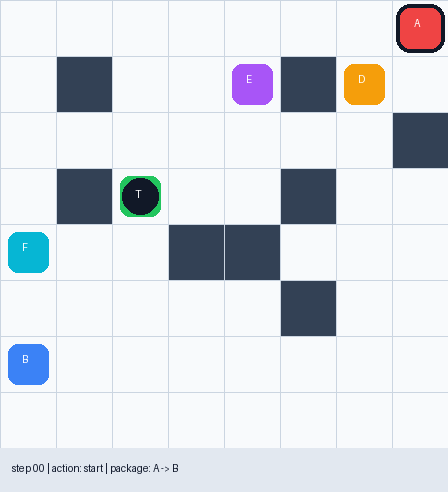

In [16]:
example = train_trajectories[0]
print("Example trajectory")
print("  layout_id:", example["layout_id"])
print("  episode_seed:", example["episode_seed"])
print("  num_steps:", example["num_steps"])
print("  actions:", [ACTION_NAMES[a] for a in example["actions"]])

obs0 = example["observations"][0]
print("\nObservation")
print("  grid shape:", obs0["grid"].shape)
print("  vector shape:", obs0["vector"].shape)
print("  valid actions:", [ACTION_NAMES[i] for i, ok in enumerate(obs0["action_mask"]) if ok])

simulator = DeliverySimulator8x8()
simulator.reset(example["scenario"])
print("\nInitial frame")
print(simulator.render())

print("\nAnimated example")
show_episode_gif(example["scenario"], example["actions"], path="expert_demo.gif")


In [17]:
def add_target_channel(obs):
    """
    Adds a 7th channel to the grid.
    The new channel marks the current target cell:
    - before pickup: package location
    - after pickup: destination location
    """

    grid = obs["grid"].astype(np.float32)  # shape: (6, 8, 8)
    vector = obs["vector"].astype(np.float32)

    # In the notebook vector:
    # vector[5] = target_row normalized
    # vector[6] = target_col normalized
    target_row = int(round(vector[5] * (GRID_SIZE - 1)))
    target_col = int(round(vector[6] * (GRID_SIZE - 1)))

    target_channel = np.zeros((1, GRID_SIZE, GRID_SIZE), dtype=np.float32)
    target_channel[0, target_row, target_col] = 1.0

    enhanced_grid = np.concatenate([grid, target_channel], axis=0)

    return enhanced_grid

In [18]:
def flatten_observation(obs):
    """Flatten one observation into a feature vector."""
    return np.concatenate([
        obs["grid"].astype(np.float32).reshape(-1),
        obs["vector"].astype(np.float32),
    ])


class CNNActionDataset(torch.utils.data.Dataset):
    def __init__(self, trajectories):
        self.samples = [
            (obs, int(action))
            for trajectory in trajectories
            for obs, action in zip(
                trajectory["observations"],
                trajectory["actions"],
                strict=True
            )
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        obs, action = self.samples[idx]

        grid = torch.tensor(add_target_channel(obs), dtype=torch.float32)
        vector = torch.tensor(obs["vector"], dtype=torch.float32)
        mask = torch.tensor(obs["action_mask"], dtype=torch.bool)
        y = torch.tensor(action, dtype=torch.long)

        return grid, vector, mask, y


train_dataset = CNNActionDataset(train_trajectories)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

grid0, vector0, mask0, y0 = train_dataset[0]
action_counts = Counter(int(train_dataset[i][3]) for i in range(len(train_dataset)))
print("Created dataset")
print("  state-action samples:", len(train_dataset))
print("  vector dimension:", vector0.numel())
print("  first action:", int(y0), ACTION_NAMES[int(y0)])
print("  action counts:", {ACTION_NAMES[k]: v for k, v in action_counts.items()})

Created dataset
  state-action samples: 5327
  vector dimension: 13
  first action: 1 north
  action counts: {'north': 1148, 'east': 1120, 'pickup': 400, 'south': 1066, 'west': 1193, 'dropoff': 400}


In [19]:
class CNNActionModel(nn.Module):
    def __init__(self, vector_dim=13, num_actions=6):
        super().__init__()

        self.grid_net = nn.Sequential(
            nn.Conv2d(7, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Flatten()
        )

        # Después de 3 convs, la salida sigue siendo 64 × 8 × 8
        grid_feature_dim = 64 * 8 * 8

        self.vector_net = nn.Sequential(
            nn.Linear(vector_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(grid_feature_dim + 64, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_actions)
        )

    def forward(self, grid, vector):
        grid_features = self.grid_net(grid)
        vector_features = self.vector_net(vector)

        features = torch.cat([grid_features, vector_features], dim=1)
        logits = self.head(features)

        return logits

from collections import Counter

# Como ahora el dataset devuelve (x, mask, y), la acción está en índice 2
action_counts = Counter(int(train_dataset[i][3]) for i in range(len(train_dataset)))

print("Action counts:", action_counts)

num_actions = 6
counts = torch.zeros(num_actions, dtype=torch.float32)

for action_id, count in action_counts.items():
    counts[action_id] = count

class_weights = counts.sum() / (num_actions * counts.clamp(min=1))
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(DEVICE)

print("Class weights:", class_weights)


model = CNNActionModel(vector_dim=vector0.numel()).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))


Action counts: Counter({3: 1193, 1: 1148, 2: 1120, 0: 1066, 4: 400, 5: 400})
Class weights: tensor([0.6591, 0.6120, 0.6273, 0.5889, 1.7564, 1.7564])
CNNActionModel(
  (grid_net): Sequential(
    (0): Conv2d(7, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (vector_net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=4160, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)
parameters: 1161414


In [20]:
@torch.no_grad()
def train_action_accuracy():
    model.eval()
    correct = 0
    total = 0

    for grid, vector, mask, y in DataLoader(train_dataset, batch_size=1024):
        grid = grid.to(DEVICE)
        vector = vector.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(grid, vector)
        logits = logits.masked_fill(~mask, -1e9)

        pred = logits.argmax(dim=1)

        correct += int((pred == y).sum().item())
        total += y.size(0)

    return correct / total


EPOCHS = 30
for epoch in tqdm(range(1, EPOCHS + 1)):
    model.train()
    total_loss = total_examples = 0

    for grid, vector, mask, y in train_loader:
        grid = grid.to(DEVICE)
        vector = vector.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(grid, vector)
        logits = logits.masked_fill(~mask, -1e9)

        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    print(f"epoch {epoch:02d} | loss {total_loss / total_examples:.4f}")

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:02d} | loss {total_loss / total_examples:.4f} | train action acc {train_action_accuracy():.3f}")


  0%|          | 0/30 [00:00<?, ?it/s]

epoch 01 | loss 0.8412
epoch 01 | loss 0.8412 | train action acc 0.518
epoch 02 | loss 0.5799
epoch 03 | loss 0.3042
epoch 04 | loss 0.2212
epoch 05 | loss 0.1845
epoch 05 | loss 0.1845 | train action acc 0.930
epoch 06 | loss 0.1650
epoch 07 | loss 0.1569
epoch 08 | loss 0.1457
epoch 09 | loss 0.1293
epoch 10 | loss 0.1164
epoch 10 | loss 0.1164 | train action acc 0.961
epoch 11 | loss 0.1051
epoch 12 | loss 0.0943
epoch 13 | loss 0.0847
epoch 14 | loss 0.0741
epoch 15 | loss 0.0639
epoch 15 | loss 0.0639 | train action acc 0.983
epoch 16 | loss 0.0545
epoch 17 | loss 0.0441
epoch 18 | loss 0.0465
epoch 19 | loss 0.0330
epoch 20 | loss 0.0262
epoch 20 | loss 0.0262 | train action acc 0.992
epoch 21 | loss 0.0263
epoch 22 | loss 0.0225
epoch 23 | loss 0.0139
epoch 24 | loss 0.0166
epoch 25 | loss 0.0120
epoch 25 | loss 0.0120 | train action acc 0.997
epoch 26 | loss 0.0085
epoch 27 | loss 0.0052
epoch 28 | loss 0.0056
epoch 29 | loss 0.0031
epoch 30 | loss 0.0014
epoch 30 | loss 0.0014

In [21]:
@torch.no_grad()
def model_action(obs):
    model.eval()

    grid = torch.tensor(
        add_target_channel(obs),
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    vector = torch.tensor(
        obs["vector"],
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    mask = torch.tensor(
        obs["action_mask"],
        dtype=torch.bool,
        device=DEVICE
    )

    logits = model(grid, vector).squeeze(0)
    logits = logits.masked_fill(~mask, -1e9)

    return int(logits.argmax().item())


def run_episode(scenario, action_fn, max_steps=MAX_STEPS, render=False):
    """Run an action model on one scenario."""
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)
    frames, actions = [], []
    invalid_pickup_or_dropoff = 0
    done = False

    if render:
        frames.append(simulator.render())

    for _ in range(max_steps):
        action = int(action_fn(simulator.observation()))
        _, done, timed_out, info = simulator.step(action)
        actions.append(action)
        invalid_pickup_or_dropoff += int(info["invalid_pickup_or_dropoff"])
        if render:
            frames.append(simulator.render())
        if done or timed_out:
            break

    return {
        "success": done,
        "steps": len(actions),
        "invalid_pickup_or_dropoff": invalid_pickup_or_dropoff,
        "actions": actions,
        "frames": frames,
    }


def evaluate_action_model(scenarios, action_fn, limit=None):
    """Evaluate complete-episode success on a scenario list."""
    results = [run_episode(s, action_fn) for s in tqdm(scenarios[:limit])]
    return {
        "success_rate": float(np.mean([r["success"] for r in results])),
        "avg_steps": float(np.mean([r["steps"] for r in results])),
        "avg_invalid_pickup_or_dropoff": float(np.mean([r["invalid_pickup_or_dropoff"] for r in results])),
        "results": results,
    }


rng = np.random.default_rng(SEED)


def random_action_model(obs):
    """Sample a random action."""
    return int(rng.integers(6))


def cnn_action_model(obs):
    return model_action(obs)


In [22]:
EVAL_LIMIT = None

random_eval = evaluate_action_model(valid_scenarios, random_action_model, limit=EVAL_LIMIT)
cnn_eval = evaluate_action_model(valid_scenarios, cnn_action_model, limit=EVAL_LIMIT)

for name, metrics in [("random", random_eval), ("CNN", cnn_eval)]:
    print(name, {k: v for k, v in metrics.items() if k != "results"})


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

random {'success_rate': 0.035, 'avg_steps': 119.035, 'avg_invalid_pickup_or_dropoff': 39.055}
CNN {'success_rate': 0.73, 'avg_steps': 41.405, 'avg_invalid_pickup_or_dropoff': 0.0}


success: True
steps: 18
invalid pickup/dropoff: 0
actions: ['north', 'north', 'west', 'north', 'west', 'north', 'north', 'west', 'west', 'west', 'pickup', 'south', 'south', 'south', 'west', 'south', 'south', 'dropoff']
initial frame:
 #  D  C  .  B  .  .  .
 .  .  .  .  .  #  #  #
 .  .  #  .  .  .  #  .
 .  .  .  .  .  .  .  .
 .  #  .  .  .  .  .  .
 F  .  .  .  .  .  T  .
 .  A  #  .  .  .  E  .
 .  .  .  .  .  .  .  .
package=D, destination=F
final frame:
 #  D  C  .  B  .  .  .
 .  .  .  .  .  #  #  #
 .  .  #  .  .  .  #  .
 .  .  .  .  .  .  .  .
 .  #  .  .  .  .  .  .
 T  .  .  .  .  .  .  .
 .  A  #  .  .  .  E  .
 .  .  .  .  .  .  .  .
package=F, destination=F
animated rollout:


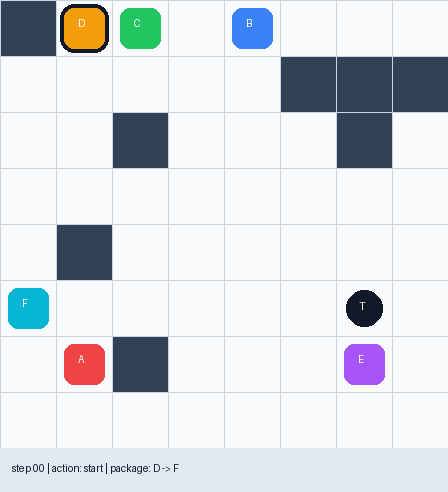

In [24]:
example_run = run_episode(valid_scenarios[0], cnn_action_model, render=True)
print("success:", example_run["success"])
print("steps:", example_run["steps"])
print("invalid pickup/dropoff:", example_run["invalid_pickup_or_dropoff"])
print("actions:", [ACTION_NAMES[a] for a in example_run["actions"]])
print("initial frame:")
print(example_run["frames"][0])
print("final frame:")
print(example_run["frames"][-1])

print("animated rollout:")
show_episode_gif(valid_scenarios[0], example_run["actions"], path="model_rollout.gif")


In [26]:
def generate_predictions(scenarios, action_fn, limit=None):
    """Generate action sequences for scenarios."""
    predictions = []
    for scenario in tqdm(scenarios[:limit], desc="Generating predictions"):
        episode = run_episode(scenario, action_fn)
        predictions.append({
            "layout_id": scenario["layout_id"],
            "episode_seed": scenario["episode_seed"],
            "actions": episode["actions"],
        })
    return predictions


def save_predictions_zip(predictions, path="predictions.zip"):
    """Write predictions.jsonl into a zip file."""
    jsonl_path = Path("predictions.jsonl")
    with jsonl_path.open("w", encoding="utf-8") as f:
        for pred in predictions:
            f.write(json.dumps(pred) + "\n")
    with zipfile.ZipFile(path, "w") as zf:
        zf.write(jsonl_path, "predictions.jsonl")
    print(f"Saved {path}")


# For a real submission, use limit=None.
test_predictions_preview = generate_predictions(test_scenarios, cnn_action_model, limit=5)
test_predictions_preview[0]


Generating predictions:   0%|          | 0/5 [00:00<?, ?it/s]

{'layout_id': 'test_0000',
 'episode_seed': 300000,
 'actions': [0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1]}

In [28]:
test_predictions = generate_predictions(test_scenarios, cnn_action_model, limit=None)
save_predictions_zip(test_predictions, "predictions.zip")

Generating predictions:   0%|          | 0/1600 [00:00<?, ?it/s]

Saved predictions.zip


Idea/ver el input, si es acorde al modelo